In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"D:\Merceds\archive\Mercedes_Stock.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1996-10-30,37.848667,37.878437,37.521210,37.550976,9.887261,1640521
1,1996-10-31,37.635983,38.057022,37.635983,38.052780,10.019385,1908031
2,1996-11-01,38.273941,38.614124,38.082554,38.231346,10.066402,2423211
3,1996-11-04,38.273941,38.609882,38.273941,38.529037,10.144786,1284644
4,1996-11-05,38.694889,39.251991,38.507828,39.251991,10.335141,2105206


In [3]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (7511, 7)
<class 'pandas.DataFrame'>
RangeIndex: 7511 entries, 0 to 7510
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       7511 non-null   datetime64[us]
 1   Open       7511 non-null   float64       
 2   High       7511 non-null   float64       
 3   Low        7511 non-null   float64       
 4   Close      7511 non-null   float64       
 5   Adj Close  7511 non-null   float64       
 6   Volume     7511 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 410.9 KB


,Date,Open,High,Low,Close,Adj Close,Volume
count,7511,7511.000000,7511.000000,7511.000000,7511.000000,7511.000000,7.511000e+03
mean,2011-05-28 12:57:48.193316,46.944158,47.513845,46.335167,46.922789,24.420731,5.469589e+06
min,1996-10-30 00:00:00,14.688660,15.108692,14.306056,14.505675,5.894059,0.000000e+00
25%,2004-01-10 12:00:00,34.534153,34.933392,33.997677,34.482170,12.959133,2.922422e+06
50%,2011-05-12 00:00:00,46.943829,47.492779,46.378239,46.952145,18.220886,4.604369e+06
75%,2018-10-01 12:00:00,57.837927,58.389004,57.136365,57.785747,32.315592,6.842950e+06
max,2026-02-25 00:00:00,85.521103,92.282379,84.542969,85.052834,65.410294,7.396760e+07
std,NaN,14.638879,14.745941,14.532735,14.626208,14.987799,4.100571e+06


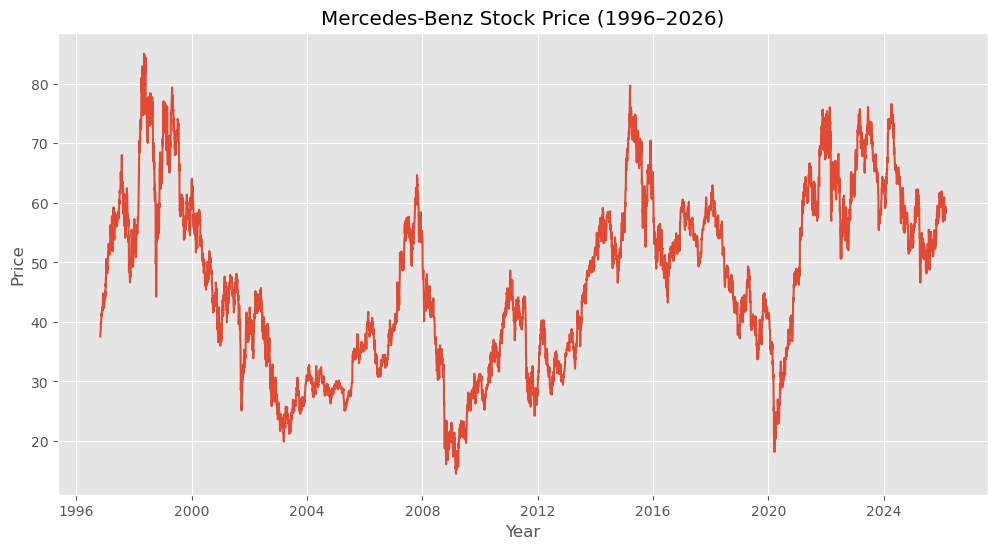

In [4]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.title("Mercedes-Benz Stock Price (1996–2026)")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [5]:
df["daily_return"] = df["Close"].pct_change()

df["daily_return"].describe()

count    7510.000000
mean        0.000289
std         0.021443
min        -0.188521
25%        -0.010210
50%         0.000000
75%         0.010559
max         0.272767
Name: daily_return, dtype: float64

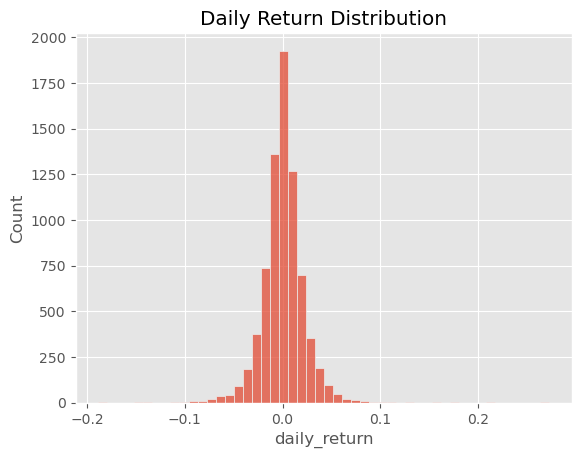

In [6]:
plt.figure()

sns.histplot(df["daily_return"].dropna(), bins=50)

plt.title("Daily Return Distribution")

plt.show()

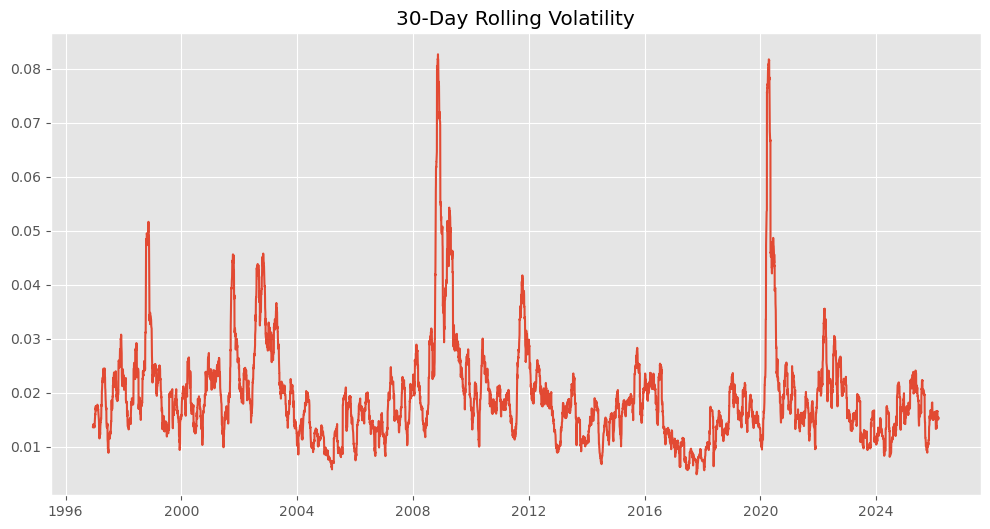

In [7]:
df["volatility_30"] = df["daily_return"].rolling(30).std()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["volatility_30"])

plt.title("30-Day Rolling Volatility")

plt.show()

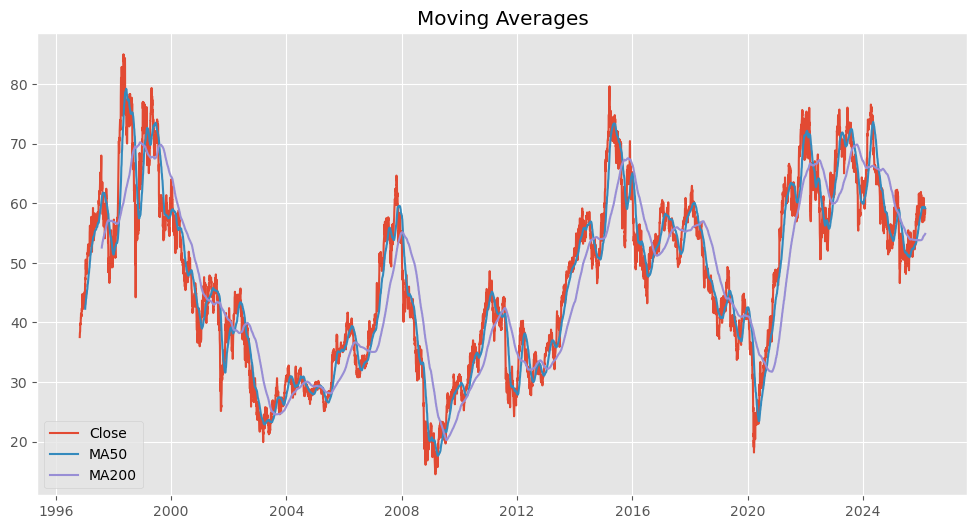

In [8]:
df["MA50"] = df["Close"].rolling(50).mean()

df["MA200"] = df["Close"].rolling(200).mean()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.plot(df["Date"], df["MA200"], label="MA200")

plt.legend()

plt.title("Moving Averages")

plt.show()

In [9]:
df["golden_cross"] = (df["MA50"] > df["MA200"]).astype(int)

df["cross_signal"] = df["golden_cross"].diff()

df[df["cross_signal"] == 1][["Date","Close"]].head()

,Date,Close
199,1997-08-05,63.194500
356,1998-03-12,69.212029
588,1999-02-01,76.628891
1161,2001-04-12,43.791504
1403,2002-03-18,44.523441


In [10]:
df["crash"] = df["daily_return"] < -0.05

crashes = df[df["crash"]]

crashes[["Date","daily_return"]].head()

,Date,daily_return
256,1997-10-23,-0.053167
259,1997-10-28,-0.071283
297,1997-12-19,-0.067980
411,1998-05-28,-0.090256
476,1998-08-27,-0.052872


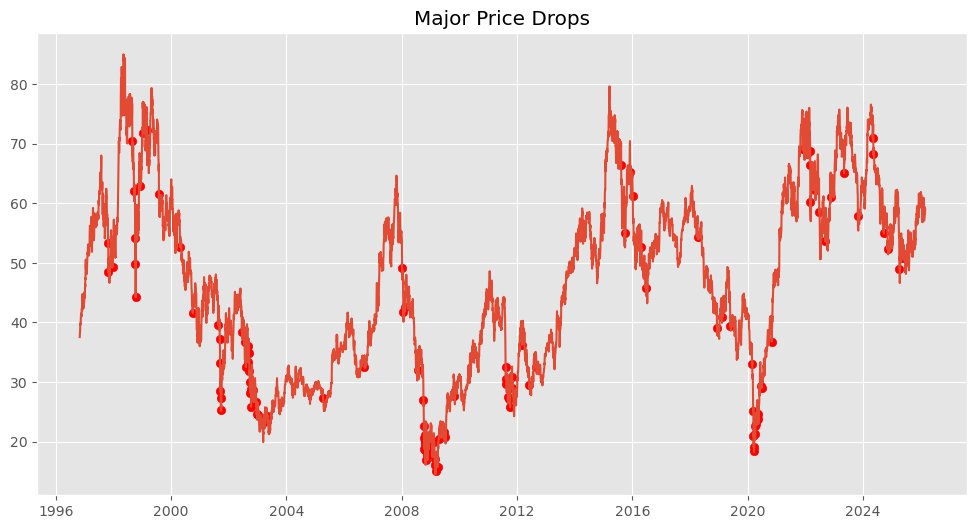

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.scatter(crashes["Date"], crashes["Close"], color="red")

plt.title("Major Price Drops")

plt.show()

In [12]:
df["return"] = df["Close"].pct_change()

df["MA10"] = df["Close"].rolling(10).mean()

df["MA20"] = df["Close"].rolling(20).mean()

df["volume_change"] = df["Volume"].pct_change()

df["volatility"] = df["return"].rolling(10).std()

In [13]:
df["target"] = df["Close"].shift(-1)

In [14]:
features = [
"Open",
"High",
"Low",
"Close",
"Volume",
"MA10",
"MA20",
"volatility"
]

data = df.dropna()

X = data[features]

y = data["target"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [16]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
predictions = model.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)

print("R2 Score:", r2)

RMSE: 0.9774768791423428
R2 Score: 0.9958603569488979


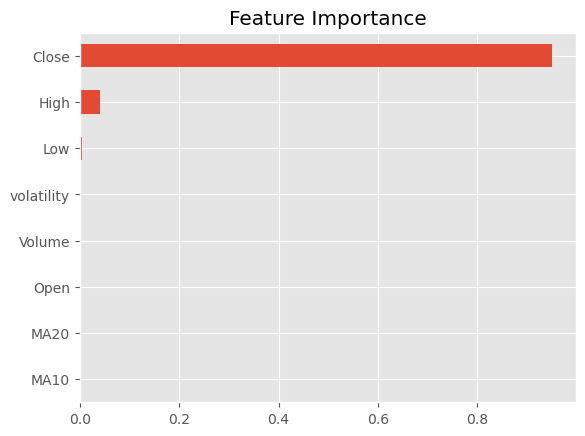

In [19]:
importance = pd.Series(model.feature_importances_, index=features)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

In [20]:
print("Dataset Range:", df["Date"].min(), "to", df["Date"].max())

print("Total Trading Days:", len(df))

print("Largest Daily Drop:", df["daily_return"].min())

print("Largest Daily Gain:", df["daily_return"].max())

Dataset Range: 1996-10-30 00:00:00 to 2026-02-25 00:00:00
Total Trading Days: 7511
Largest Daily Drop: -0.18852062784121937
Largest Daily Gain: 0.27276677807189675
